## Import data, annotate boltz training cutoff date for PDB


In [57]:
import polars as pl
import datetime as dt

boltz_cutoff = dt.datetime(2023, 6, 1, tzinfo=dt.timezone.utc)

pdb_af3 = pl.read_parquet("../../data/pdb/triad/staged/pdb_triad.af3_rmsd.parquet")
pdb_boltz = pl.read_parquet(
    "../../data/pdb/triad/staged/pdb_triad.boltz_rmsd.parquet"
).with_columns(
    pl.when(pl.col("pdb_date") < boltz_cutoff)
    .then(pl.lit(True))
    .otherwise(pl.lit(False))
    .alias("boltz_pre_cutoff")
)

## Plotting methods


In [58]:
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
from matplotlib.patches import Patch
from scipy import stats


def plot_rmsd_bars(
    pdb_df: pl.DataFrame, inf_type: str, title: str | None = None
) -> plt.Figure:
    n = pdb_df.height

    replic_means = (
        pdb_df.filter(pl.col("replication"))
        .select(
            pl.col(f"peptide_rmsd_{inf_type}_4"),
            pl.col(f"mhc_rmsd_{inf_type}_4"),
            pl.col(f"tcr_rmsd_{inf_type}_4"),
            pl.col(f"cdr_rmsd_{inf_type}_4"),
        )
        .to_numpy()
    )
    post_means = (
        pdb_df.filter(~pl.col("replication"))
        .select(
            pl.col(f"peptide_rmsd_{inf_type}_4"),
            pl.col(f"mhc_rmsd_{inf_type}_4"),
            pl.col(f"tcr_rmsd_{inf_type}_4"),
            pl.col(f"cdr_rmsd_{inf_type}_4"),
        )
        .to_numpy()
    )

    labels = ["Peptide RMSD", "MHC RMSD", "TCR RMSD", "CDR RMSD"]
    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))

    # pre-training boxplots (blue)
    ax.boxplot(
        replic_means,
        positions=x - width / 2,
        widths=width,
        patch_artist=True,
        boxprops=dict(facecolor="tab:blue", edgecolor="black"),
        whiskerprops=dict(color="tab:blue"),
        capprops=dict(color="tab:blue"),
        medianprops=dict(color="black"),
        flierprops=dict(markeredgecolor="tab:blue"),
    )

    # post-training boxplots (orange)
    ax.boxplot(
        post_means,
        positions=x + width / 2,
        widths=width,
        patch_artist=True,
        boxprops=dict(facecolor="tab:orange", edgecolor="black"),
        whiskerprops=dict(color="tab:orange"),
        capprops=dict(color="tab:orange"),
        medianprops=dict(color="black"),
        flierprops=dict(markeredgecolor="tab:orange"),
    )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")

    # y-axis label
    ax.set_ylabel(f"RMSD between true and crystal structure (Å) {inf_type.upper()}")

    if title:
        ax.set_title(title)

    pre_patch = Patch(
        facecolor="tab:blue",
        edgecolor="black",
        label=f"Pre-training (n={replic_means.shape[0]})",
    )
    post_patch = Patch(
        facecolor="tab:orange",
        edgecolor="black",
        label=f"Post-training (n={post_means.shape[0]})",
    )
    ax.legend(handles=[pre_patch, post_patch], loc="upper right")

    plt.tight_layout()
    return fig


def plot_rmsd_compare(
    df_af3: pl.DataFrame,
    df_boltz: pl.DataFrame,
    rmsd_type: str,
    title: str | None = None,
) -> plt.Figure:
    """
    Compare a single RMSD type between AF3 and Boltz models.
    For each model we plot two boxplots (pre- and post-training cutoff),
    annotate legend entries with sample counts, and compute
    Spearman correlation + two-sided paired t-test on matching PDB IDs.
    """
    # Column names
    col_af3 = f"{rmsd_type}_rmsd_af3_4"
    col_boltz = f"{rmsd_type}_rmsd_boltz_4"

    # Prepare pre/post subsets and counts
    af3_pre = df_af3.filter(pl.col("replication"))
    af3_post = df_af3.filter(~pl.col("replication"))
    bolt_pre = df_boltz.filter(pl.col("boltz_pre_cutoff"))
    bolt_post = df_boltz.filter(~pl.col("boltz_pre_cutoff"))

    n_af3_pre = af3_pre.height
    n_af3_post = af3_post.height
    n_bolt_pre = bolt_pre.height
    n_bolt_post = bolt_post.height

    # Boxplot data
    pre_af3_vals = af3_pre.select(pl.col(col_af3)).to_numpy().flatten()
    post_af3_vals = af3_post.select(pl.col(col_af3)).to_numpy().flatten()
    pre_bolt_vals = bolt_pre.select(pl.col(col_boltz)).to_numpy().flatten()
    post_bolt_vals = bolt_post.select(pl.col(col_boltz)).to_numpy().flatten()

    # Build matched datasets on 'pdb'
    # Pre-training matched
    joined_pre = af3_pre.select(["pdb", pl.col(col_af3).alias("af3")]).join(
        bolt_pre.select(["pdb", pl.col(col_boltz).alias("bolt")]),
        on="pdb",
        how="inner",
    )
    arr_af3_pre = joined_pre["af3"].to_numpy()
    arr_bolt_pre = joined_pre["bolt"].to_numpy()

    # Post-training matched
    joined_post = af3_post.select(["pdb", pl.col(col_af3).alias("af3")]).join(
        bolt_post.select(["pdb", pl.col(col_boltz).alias("bolt")]),
        on="pdb",
        how="inner",
    )
    arr_af3_post = joined_post["af3"].to_numpy()
    arr_bolt_post = joined_post["bolt"].to_numpy()

    # Compute Spearman + paired t-test
    rho_pre, p_s_pre = stats.spearmanr(arr_af3_pre, arr_bolt_pre)
    t_pre, p_t_pre = stats.ttest_rel(arr_af3_pre, arr_bolt_pre)
    rho_post, p_s_post = stats.spearmanr(arr_af3_post, arr_bolt_post)
    t_post, p_t_post = stats.ttest_rel(arr_af3_post, arr_bolt_post)

    # Set up plot
    x = np.array([0, 1])
    width = 0.3
    fig, ax = plt.subplots(figsize=(8, 5))

    # Plot AF3
    ax.boxplot(
        pre_af3_vals,
        positions=[x[0] - width / 2],
        widths=width,
        patch_artist=True,
        boxprops=dict(facecolor="tab:blue", edgecolor="black"),
        whiskerprops=dict(color="tab:blue"),
        capprops=dict(color="tab:blue"),
        medianprops=dict(color="white"),
        flierprops=dict(markeredgecolor="tab:blue"),
    )
    ax.boxplot(
        post_af3_vals,
        positions=[x[0] + width / 2],
        widths=width,
        patch_artist=True,
        boxprops=dict(facecolor="tab:orange", edgecolor="black"),
        whiskerprops=dict(color="tab:orange"),
        capprops=dict(color="tab:orange"),
        medianprops=dict(color="white"),
        flierprops=dict(markeredgecolor="tab:orange"),
    )

    # Plot Boltz
    ax.boxplot(
        pre_bolt_vals,
        positions=[x[1] - width / 2],
        widths=width,
        patch_artist=True,
        boxprops=dict(facecolor="tab:green", edgecolor="black"),
        whiskerprops=dict(color="tab:green"),
        capprops=dict(color="tab:green"),
        medianprops=dict(color="white"),
        flierprops=dict(markeredgecolor="tab:green"),
    )
    ax.boxplot(
        post_bolt_vals,
        positions=[x[1] + width / 2],
        widths=width,
        patch_artist=True,
        boxprops=dict(facecolor="tab:red", edgecolor="black"),
        whiskerprops=dict(color="tab:red"),
        capprops=dict(color="tab:red"),
        medianprops=dict(color="white"),
        flierprops=dict(markeredgecolor="tab:red"),
    )

    # Labels
    ax.set_xticks(x)
    ax.set_xticklabels(["AF3", "Boltz"])
    ax.set_ylabel(f"{rmsd_type.upper()} RMSD (Å)")
    if title:
        ax.set_title(title)

    # Legend with counts
    legend_handles = [
        Patch(
            facecolor="tab:blue", edgecolor="black", label=f"AF3 pre (n={n_af3_pre})"
        ),
        Patch(
            facecolor="tab:orange",
            edgecolor="black",
            label=f"AF3 post (n={n_af3_post})",
        ),
        Patch(
            facecolor="tab:green",
            edgecolor="black",
            label=f"Boltz pre (n={n_bolt_pre})",
        ),
        Patch(
            facecolor="tab:red",
            edgecolor="black",
            label=f"Boltz post (n={n_bolt_post})",
        ),
    ]
    ax.legend(handles=legend_handles, loc="upper right")

    stats_text = (
        f"\nPre-cutoff intersection AF3 vs Boltz:\n  n={len(arr_af3_pre)},\n  Spearman ρ={rho_pre:.2f} (p={p_s_pre:.2g}),\n  t={t_pre:.2f} (p={p_t_pre:.2g})\n\n"
        f"Post-cutoff intersection AF3 vs Boltz:\n  n={len(arr_af3_post)},\n  Spearman ρ={rho_post:.2f} (p={p_s_post:.2g}),\n  t={t_post:.2f} (p={p_t_post:.2g})"
    )
    # legend_handles.append(Patch(facecolor="none", edgecolor="none", label=stats_text))

    ax.legend(handles=legend_handles, loc="upper right")

    # Annotate stats
    print(stats_text)
    # ax.text(
    #     1.01,
    #     0.8,
    #     stats_text,
    #     transform=ax.transAxes,
    #     fontsize=8,
    #     bbox=dict(boxstyle="round", facecolor="white", alpha=0.6),
    # )

    plt.tight_layout()
    return fig


def plot_rmsd_scatter(
    df_af3: pl.DataFrame,
    df_boltz: pl.DataFrame,
    rmsd_type: str,
    title: str | None = None,
) -> plt.Figure:
    """
    Compare a single RMSD type between AF3 and Boltz models.
    For each model we plot two boxplots (pre- and post-training cutoff),
    annotate legend entries with sample counts, and compute
    Spearman correlation + two-sided paired t-test on matching PDB IDs.
    """
    # Column names
    col_af3 = f"{rmsd_type}_rmsd_af3_4"
    col_boltz = f"{rmsd_type}_rmsd_boltz_4"

    # Boxplot data
    af3_vals = df_af3.select(pl.col(col_af3)).to_numpy().flatten()
    af3_in_training = df_af3.select(pl.col("replication")).to_series().to_numpy()
    bolt_vals = df_boltz.select(pl.col(col_boltz)).to_numpy().flatten()
    boltz_in_training = (
        df_boltz.select(pl.col("boltz_pre_cutoff")).to_series().to_numpy()
    )

    m_af3_only = af3_in_training & ~boltz_in_training
    m_boltz_only = boltz_in_training & ~af3_in_training
    m_both = af3_in_training & boltz_in_training
    m_neither = ~af3_in_training & ~boltz_in_training

    def scatter(mask, color, label):
        if mask.any():
            ax.scatter(
                af3_vals[mask],
                bolt_vals[mask],
                c=color,
                s=20,
                alpha=0.7,
                edgecolors="none",
                label=f"{label} (n={int(mask.sum())})",
            )

    # Compute Spearman + paired t-test
    rho_pre, p_s_pre = stats.spearmanr(af3_vals, bolt_vals)
    t_pre, p_t_pre = stats.ttest_rel(af3_vals, bolt_vals)

    # Set up plot
    fig, ax = plt.subplots(figsize=(6, 6))

    scatter(m_af3_only, "blue", "AF3 in training only")
    scatter(m_boltz_only, "red", "Boltz in training only")
    scatter(m_both, "purple", "Both in training")
    scatter(m_neither, "black", "Neither in training")

    ax.text(
        0.05,
        0.95,
        f"spearman r = {rho_pre:.2f}, p = {p_s_pre:.2g}",
        transform=ax.transAxes,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.6),
    )

    ax.set_xlabel(f"AF3 {rmsd_type.upper()} RMSD (Å)")
    ax.set_xlim(0, max(af3_vals.max(), bolt_vals.max()) + 0.5)
    ax.set_ylim(0, max(af3_vals.max(), bolt_vals.max()) + 0.5)
    ax.set_ylabel(f"Boltz-2 {rmsd_type.upper()} RMSD (Å)")

    ax.legend(frameon=False, fontsize=9)
    ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.6)
    if title:
        ax.set_title(title)

    plt.tight_layout()
    return fig

## AF3 vs Boltz RMSD


### Peptide RMSD

Peptide RMSD procedure:

- Align true and best predicted structure (of 5 samples/seeds) based on the TCRDock MHC coordinate frame
- Measure RMSD of Calpha backbone peptide residues

Measures peptide orientation accuracy w.r.t MHC complex


#### MHC class I



Pre-cutoff intersection AF3 vs Boltz:
  n=89,
  Spearman ρ=0.41 (p=6.8e-05),
  t=5.65 (p=2e-07)

Post-cutoff intersection AF3 vs Boltz:
  n=10,
  Spearman ρ=0.59 (p=0.074),
  t=-0.38 (p=0.72)


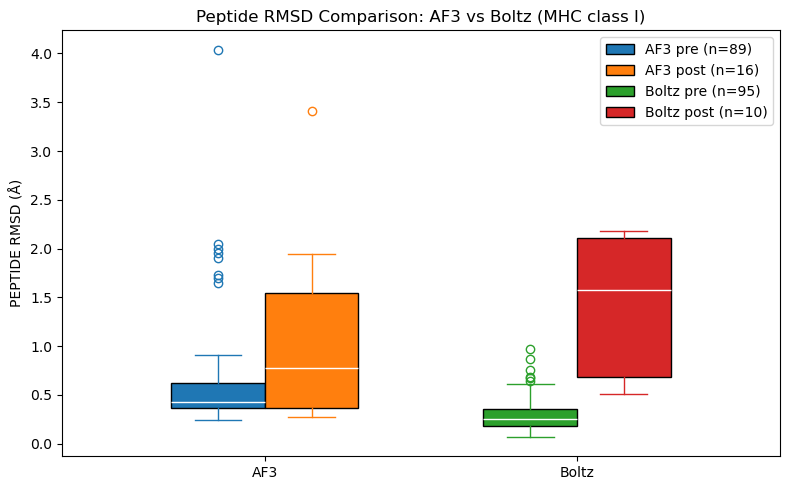

In [59]:
fig = plot_rmsd_compare(
    pdb_af3.filter(pl.col("mhc_class") == "I"),
    pdb_boltz.filter(pl.col("mhc_class") == "I"),
    "peptide",
    title="Peptide RMSD Comparison: AF3 vs Boltz (MHC class I)",
)

#### MHC class II


In [73]:
pdb_af3.sort(by="peptide_rmsd_af3_4", descending=True).select("pdb", "job_name","peptide_rmsd_af3_4")

pdb,job_name,peptide_rmsd_af3_4
str,str,f64
"""4p2o""","""817759ba776138bd1ab4cdcb4e75c9…",7.396449
"""6dfw""","""a89cd658f1f4eeaf321acb4e191e63…",6.782258
"""4grl""","""0719f50275543d7d2308a911619e78…",6.463206
"""6avg""","""1e75e0c6462671027fbf3e7764c912…",4.038538
"""4may""","""3b589623079e33e85fb4c499ecfef2…",3.913724
…,…,…
"""5tez""","""aab2bcbf77a81c1d9d2335c87adf30…",0.273314
"""4mxq""","""d39597f736a175e4171f2fa0fb4483…",0.2719
"""1nam""","""0d046784a09c8683597b7ffbf32324…",0.26642



Pre-cutoff intersection AF3 vs Boltz:
  n=41,
  Spearman ρ=0.67 (p=2e-06),
  t=3.23 (p=0.0025)

Post-cutoff intersection AF3 vs Boltz:
  n=6,
  Spearman ρ=0.71 (p=0.11),
  t=1.06 (p=0.34)


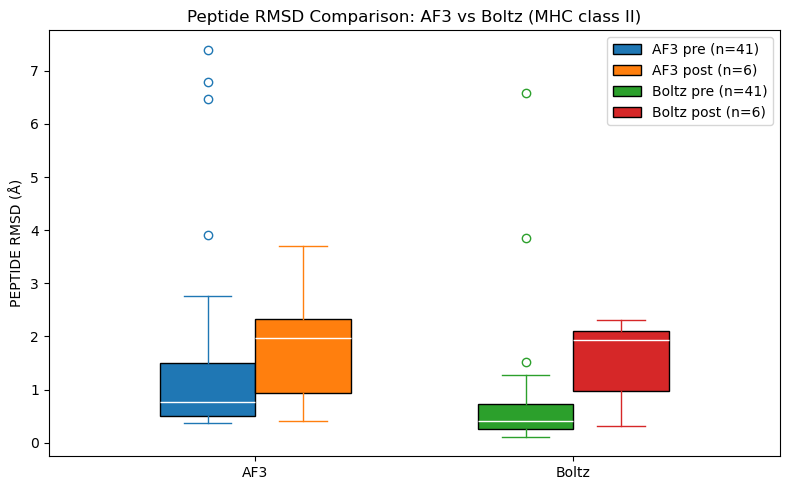

In [60]:
fig = plot_rmsd_compare(
    pdb_af3.filter(pl.col("mhc_class") == "II"),
    pdb_boltz.filter(pl.col("mhc_class") == "II"),
    "peptide",
    title="Peptide RMSD Comparison: AF3 vs Boltz (MHC class II)",
)

### CDR RMSD

CDR RMSD procedure:

- Align true and best predicted structure (of 5 samples/seeds) based on the TCRDock MHC coordinate frame
- Measure RMSD of Calphas of CDR regions, upweighting the CDR3 region by a factor of 3

Measures TCR orientation accuracy w.r.t p:MHC complex


#### Class I



Pre-cutoff intersection AF3 vs Boltz:
  n=89,
  Spearman ρ=0.26 (p=0.013),
  t=5.74 (p=1.3e-07)

Post-cutoff intersection AF3 vs Boltz:
  n=10,
  Spearman ρ=-0.18 (p=0.63),
  t=-2.59 (p=0.029)


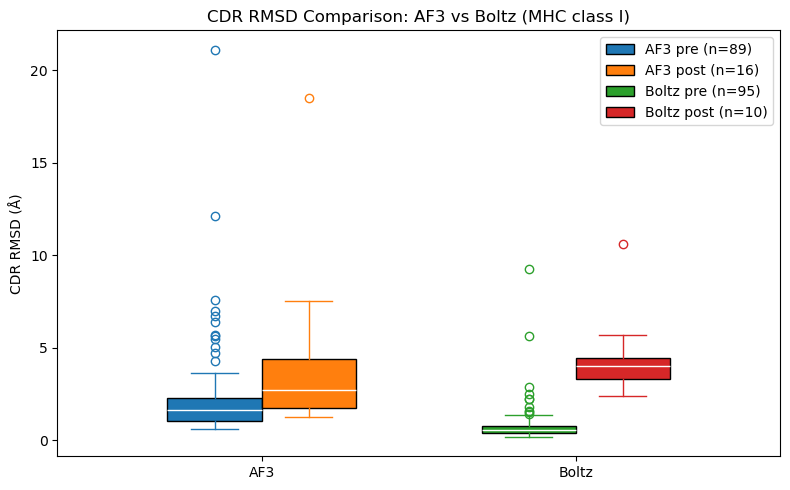

In [61]:
fig = plot_rmsd_compare(
    pdb_af3.filter(pl.col("mhc_class") == "I"),
    pdb_boltz.filter(pl.col("mhc_class") == "I"),
    "cdr",
    title="CDR RMSD Comparison: AF3 vs Boltz (MHC class I)",
)

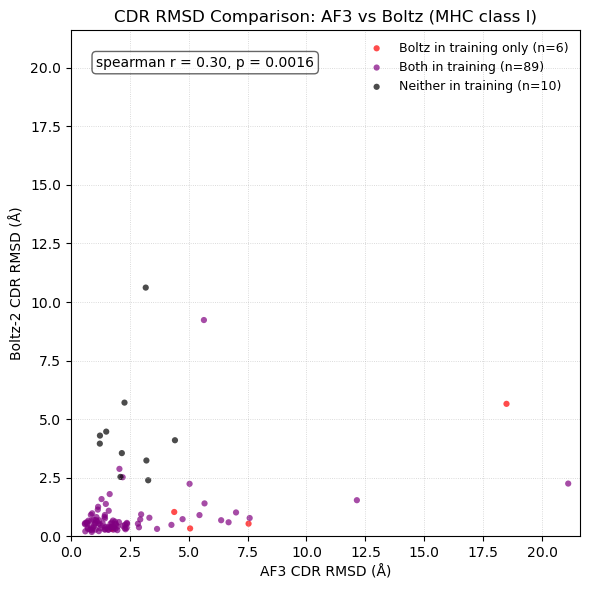

In [62]:
fig = plot_rmsd_scatter(
    pdb_af3.filter(pl.col("mhc_class") == "I"),
    pdb_boltz.filter(pl.col("mhc_class") == "I"),
    "cdr",
    title="CDR RMSD Comparison: AF3 vs Boltz (MHC class I)",
)

#### Class II



Pre-cutoff intersection AF3 vs Boltz:
  n=41,
  Spearman ρ=0.19 (p=0.23),
  t=2.68 (p=0.011)

Post-cutoff intersection AF3 vs Boltz:
  n=6,
  Spearman ρ=0.49 (p=0.33),
  t=0.67 (p=0.53)


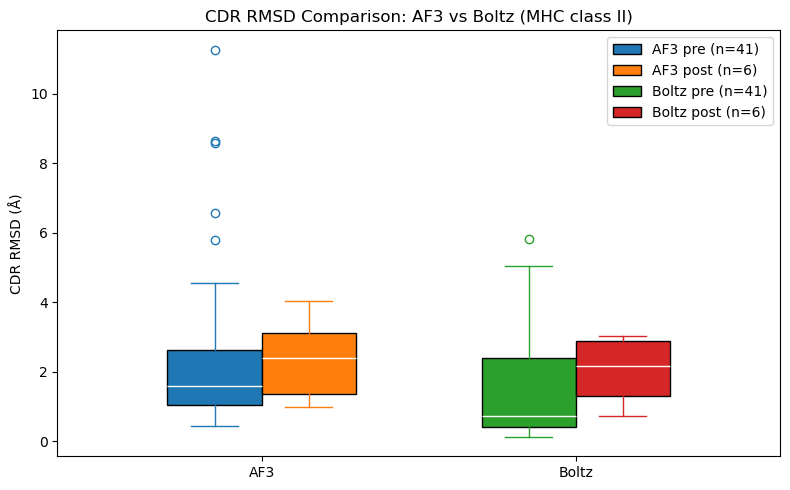

In [63]:
fig = plot_rmsd_compare(
    pdb_af3.filter(pl.col("mhc_class") == "II"),
    pdb_boltz.filter(pl.col("mhc_class") == "II"),
    "cdr",
    title="CDR RMSD Comparison: AF3 vs Boltz (MHC class II)",
)

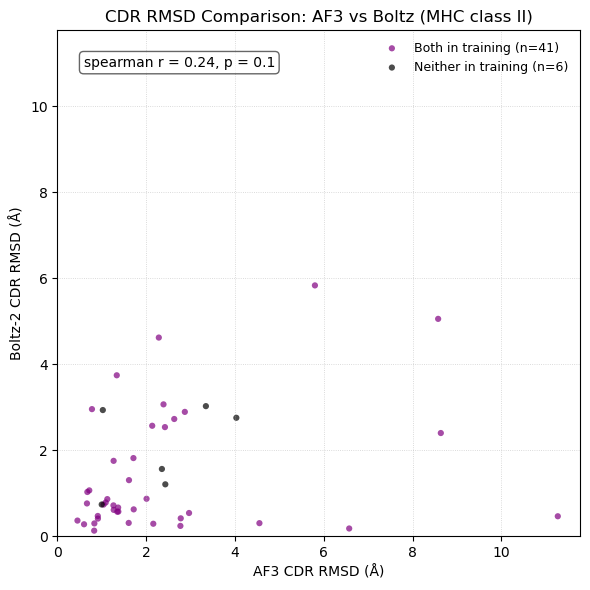

In [64]:
fig = plot_rmsd_scatter(
    pdb_af3.filter(pl.col("mhc_class") == "II"),
    pdb_boltz.filter(pl.col("mhc_class") == "II"),
    "cdr",
    title="CDR RMSD Comparison: AF3 vs Boltz (MHC class II)",
)

### MHC RMSD

MHC RMSD procedure:

- Align true and best predicted structure (of 5 samples/seeds) based on the sequence-aligned MHC residues
- Measure RMSD of Calphas of aligned MHC regions
- For class I, ignore B2M in both steps

Measures MHC structure accuracy


#### Class I



Pre-cutoff intersection AF3 vs Boltz:
  n=89,
  Spearman ρ=0.54 (p=6.2e-08),
  t=6.54 (p=4e-09)

Post-cutoff intersection AF3 vs Boltz:
  n=10,
  Spearman ρ=0.82 (p=0.0038),
  t=-0.34 (p=0.74)


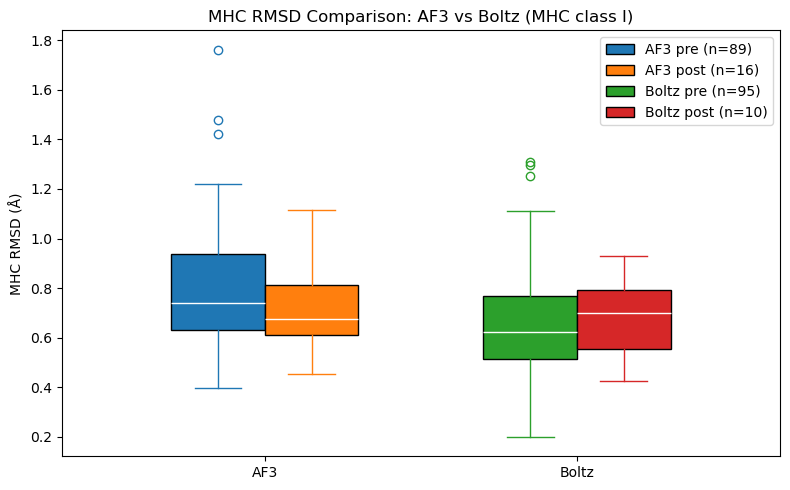

In [65]:
fig = plot_rmsd_compare(
    pdb_af3.filter(pl.col("mhc_class") == "I"),
    pdb_boltz.filter(pl.col("mhc_class") == "I"),
    "mhc",
    title="MHC RMSD Comparison: AF3 vs Boltz (MHC class I)",
)

#### Class II



Pre-cutoff intersection AF3 vs Boltz:
  n=41,
  Spearman ρ=0.75 (p=1.9e-08),
  t=3.56 (p=0.00098)

Post-cutoff intersection AF3 vs Boltz:
  n=6,
  Spearman ρ=0.26 (p=0.62),
  t=-1.42 (p=0.22)


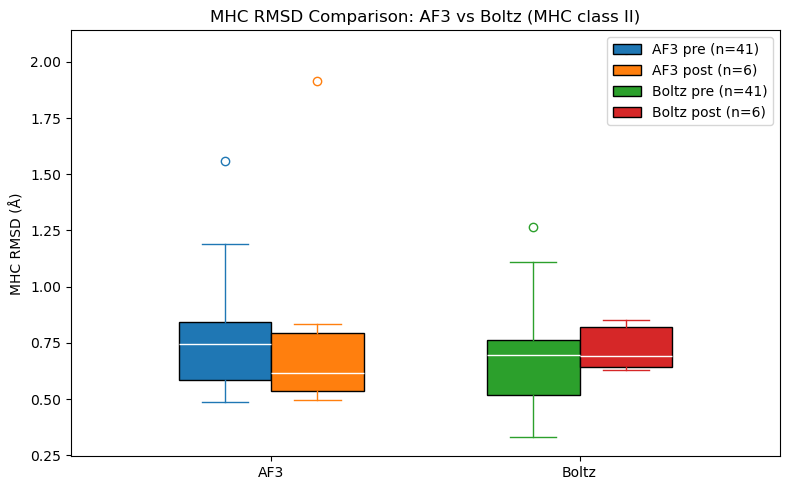

In [67]:
fig = plot_rmsd_compare(
    pdb_af3.filter(pl.col("mhc_class") == "II"),
    pdb_boltz.filter(pl.col("mhc_class") == "II"),
    "mhc",
    title="MHC RMSD Comparison: AF3 vs Boltz (MHC class II)",
)

### TCR RMSD

TCR RMSD procedure:

- Align true and best predicted structure (of 5 samples/seeds) based on the sequence-aligned TCR residues
- Measure RMSD of Calphas of aligned TCR regions

Measures TCR structure accuracy


#### Class I



Pre-cutoff intersection AF3 vs Boltz:
  n=89,
  Spearman ρ=0.31 (p=0.0034),
  t=11.59 (p=2.1e-19)

Post-cutoff intersection AF3 vs Boltz:
  n=10,
  Spearman ρ=0.28 (p=0.43),
  t=-1.05 (p=0.32)


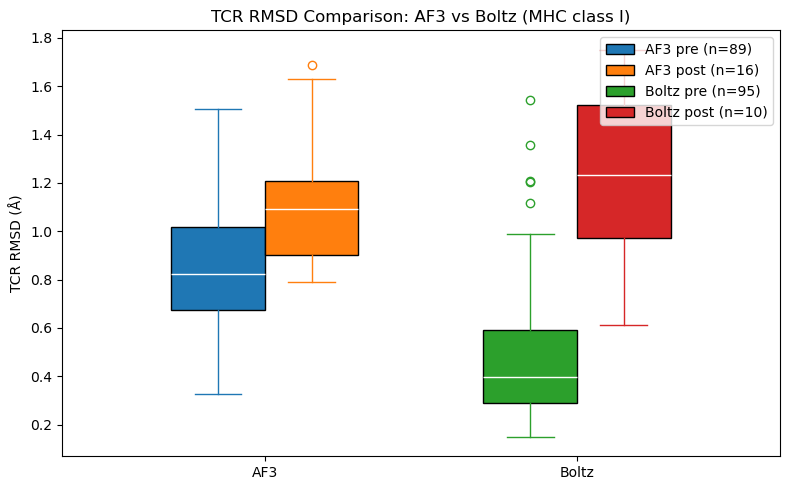

In [69]:
fig = plot_rmsd_compare(
    pdb_af3.filter(pl.col("mhc_class") == "I"),
    pdb_boltz.filter(pl.col("mhc_class") == "I"),
    "tcr",
    title="TCR RMSD Comparison: AF3 vs Boltz (MHC class I)",
)

#### Class II



Pre-cutoff intersection AF3 vs Boltz:
  n=41,
  Spearman ρ=-0.08 (p=0.6),
  t=3.52 (p=0.0011)

Post-cutoff intersection AF3 vs Boltz:
  n=6,
  Spearman ρ=0.54 (p=0.27),
  t=1.36 (p=0.23)


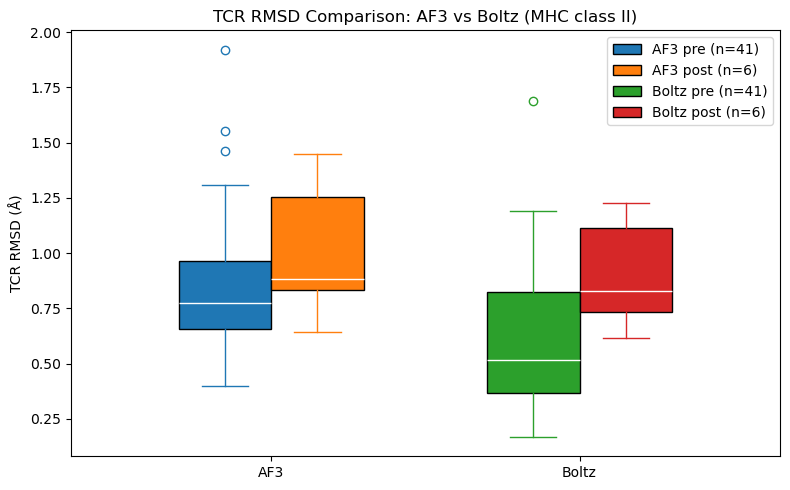

In [70]:
fig = plot_rmsd_compare(
    pdb_af3.filter(pl.col("mhc_class") == "II"),
    pdb_boltz.filter(pl.col("mhc_class") == "II"),
    "tcr",
    title="TCR RMSD Comparison: AF3 vs Boltz (MHC class II)",
)